# Load Data

In [1]:
import pandas as pd

# patch deprecate_kwarg regardless of pandas version for pandas_datareader compatibility
import pandas.util._decorators
pandas.util._decorators.deprecate_kwarg = lambda *args, **kwargs: lambda x: x
import pandas_datareader.data as web

import polars as pl
import warnings
from datetime import date
import matplotlib.pyplot as plt
from pathlib import Path
import sys

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

DATA_DIR = src_config.DATA_DIR
PROCESSED_DATA_PATH = DATA_DIR / "processed"
STACKSATS_DATA_PATH = src_config.STACKSATS_DATA_PATH
RAW_PATH = src_config.RAW_PATH

data_utils.check_stacksats_data(STACKSATS_DATA_PATH, RAW_PATH)


True

In [2]:
# (
#     pl.scan_parquet(STACKSATS_DATA_PATH)
#     .filter(
#         (pl.col("date") >= date(2018, 1, 1)) & 
#         (pl.col("date") <= date(2023, 12, 31))
#     )
#     .sink_parquet(PROCESSED_DATA_PATH / 'bitcoin_analytics_train.parquet')
# )
# print("Filtering complete. Saved to bitcoin_analytics_train.parquet")


In [3]:
# (
#     pl.scan_parquet(STACKSATS_DATA_PATH)
#     .filter(
#         (pl.col("date") >= date(2018, 1, 1)) & 
#         (pl.col("date") <= date(2025, 12, 31))
#     )
#     .sink_parquet(PROCESSED_DATA_PATH / 'bitcoin_analytics_full_2025.parquet')
# )
# print("Filtering complete. Saved to bitcoin_analytics_full_2025.parquet")


In [4]:
url = "https://drive.google.com/uc?export=download&id=1SyWrXetOSO37xvV7UWlHI9UZ1447Rzxv"

enriched_bitcoin_analytics_full_2025 = pd.read_parquet(url)
enriched_bitcoin_analytics_full_2025.to_parquet(PROCESSED_DATA_PATH / 'enriched_bitcoin_analytics_full_2025.parquet')

In [5]:
(
    pl.scan_parquet(PROCESSED_DATA_PATH / 'enriched_bitcoin_analytics_full_2025.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet(PROCESSED_DATA_PATH / 'enriched_btc_df_train.parquet')
)
print("Filtering complete. Saved to enriched_btc_df_train.parquet")


Filtering complete. Saved to enriched_btc_df_train.parquet


In [6]:
enriched_btc_df = pd.read_parquet(PROCESSED_DATA_PATH / 'enriched_bitcoin_analytics_full_2025.parquet')
enriched_btc_df = pl.from_pandas(enriched_btc_df).with_columns(pl.col('date').cast(pl.Datetime))

# Weighted strategy

In [7]:
from stacksats import StrategyRunner, BacktestConfig
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy 

if 'Treasury_90d_Delta' not in enriched_btc_df.columns:
    enriched_btc_df = enriched_btc_df.with_columns(
        ((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta')
    )

# ---------------------------------------------------------
# 1. The Continuous Linear Factor Strategy
# ---------------------------------------------------------
class LinearFactorStrategy(BaseStrategy):
    def __init__(self, w_mvrv, w_mom, w_macro, w_value):
        self.w_mvrv = w_mvrv
        self.w_mom = w_mom
        self.w_macro = w_macro
        self.w_value = w_value
        
        # Dynamic cache-busting ID
        self.strategy_id = f"linear_{w_mvrv}_{w_mom}_{w_macro}_{w_value}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        global enriched_btc_df
        macro_subset = enriched_btc_df.select(['date', 'Treasury_90d_Delta', 'MOM15', 'price_usd'])
        
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        merged = base_scores.join(macro_subset, on='date', how='inner')
        
        # Calculate the "Value Ratio": If price dropped 60%, this number goes up massively!
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        merged = merged.with_columns(
            (pl.col('price_1y_ago') / pl.col('price_usd')).fill_null(1.0).alias('value_ratio')
        )
        
        # --- THE CONTINUOUS LINEAR ALGEBRA EQUATION ---
        merged = merged.with_columns(
            (
                (pl.col('preference') * self.w_mvrv) + 
                (pl.col('MOM15') * self.w_mom) - 
                (pl.col('Treasury_90d_Delta') * self.w_macro) + 
                (pl.col('value_ratio') * self.w_value)
            ).alias('raw_score')
        )
        
        # Softmax Boundary: Clip the final output so it doesn't break the engine
        merged = merged.with_columns(
            pl.col('raw_score').clip(lower_bound=0.00001, upper_bound=1.0).alias('value')
        )
        
        return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)


# Testing

In [8]:
from stacksats import UniformStrategy, MVRVStrategy, ExportConfig

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Weighted Master Macro Strategy (2018-2023)...")

# We pick one combination to test manually!
master_strat = LinearFactorStrategy(w_mvrv=0.2, w_mom=0.1, w_macro=0.0, w_value=0.0)

# Notice we use `enriched_btc_df` so the Macro data is included!
macro_result = runner.backtest(strategy=master_strat, config=config, btc_df=enriched_btc_df)
uni_result = runner.backtest(strategy=UniformStrategy(), config=config, btc_df=enriched_btc_df)
mvrv_result = runner.backtest(strategy=MVRVStrategy(), config=config, btc_df=enriched_btc_df)

print(f"-> Weighted Master Macro Score: {macro_result.score:.2f}")
print(f"-> Weighted Master Macro Win Rate: {macro_result.win_rate:.1f}%")
print(f"-> Weighted Master Macro Exponential decay percentile: {macro_result.exp_decay_percentile:.1f}%")

print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> MVRV Exponential decay percentile: {mvrv_result.exp_decay_percentile:.1f}%")

print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(strategy=master_strat, config=export_config, btc_df=enriched_btc_df).to_dataframe()
    mvrv = runner.export(strategy=MVRVStrategy(), config=export_config, btc_df=enriched_btc_df).to_dataframe()
    base = runner.export(strategy=UniformStrategy(), config=export_config, btc_df=enriched_btc_df).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Master Macro Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

Running New Weighted Master Macro Strategy (2018-2023)...


-> Weighted Master Macro Score: 40.50
-> Weighted Master Macro Win Rate: 51.0%
-> Weighted Master Macro Exponential decay percentile: 30.0%
-> MVRV Score: 18.28
-> MVRV Win Rate: 31.3%
-> MVRV Exponential decay percentile: 5.2%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...


Total Sats (Master Macro Strategy): 50,763 Sats
Total Sats (MVRV Strategy): 51,114 Sats
Total Sats (Uniform DCA): 50,551 Sats


In [9]:
strategies_train = {
    "dynamic": master_strat,
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)   # 2018–2023
merged_train = strategy_utils.run_year_by_year(strategies_train, enriched_btc_df, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] Weighted External Tunable SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"Weighted External Tunable {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows


2018: exported 365 rows


2019: exported 365 rows


2019: exported 365 rows


2020: exported 365 rows
2020: exported 365 rows


2021: exported 365 rows
2021: exported 365 rows


2022: exported 365 rows


2022: exported 365 rows
2023: exported 365 rows


2023: exported 365 rows
[Train] Weighted External Tunable SPD : 8334.36
[Train] Baseline SPD    : 8418.79
Weighted External Tunable 1.00% worse than Uniform


# graph

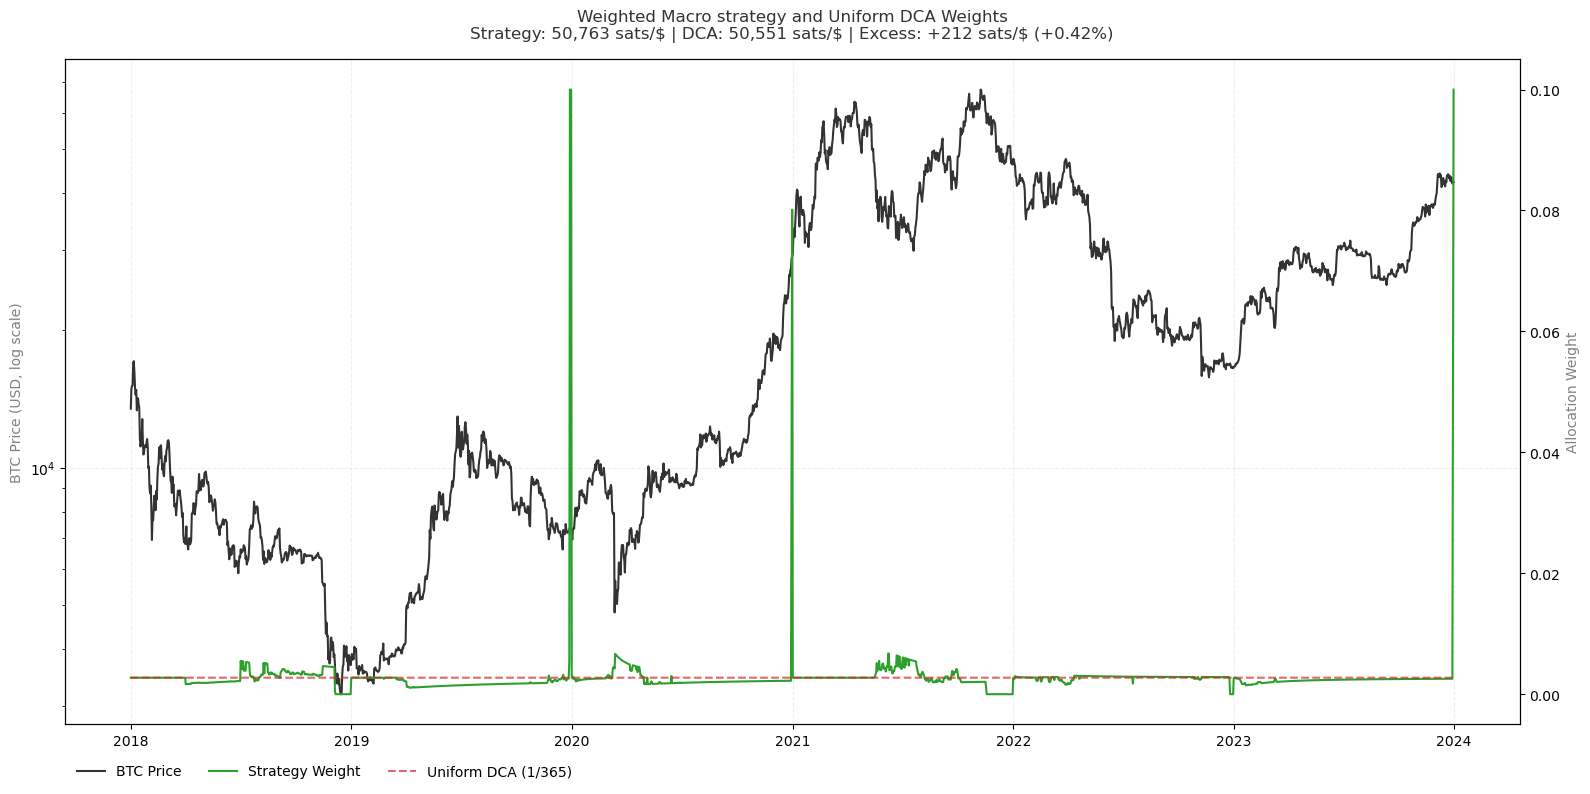

In [10]:
# 1. Sort the data perfectly by date to prevent criss-crossing
merged_sats = merged_sats.sort('date')

# 2. Calculate Sats for the entire dataset
strat_sats = merged_sats['sats_accumulated_dynamic'].sum()
base_sats = merged_sats['sats_accumulated_baseline'].sum()
diff = strat_sats - base_sats
pct = (diff / base_sats) * 100 if base_sats > 0 else 0

# Create the beautiful, single-line Title Text
title_text = (
    "Weighted Macro strategy and Uniform DCA Weights\n"
    f"Strategy: {strat_sats:,.0f} sats/$ | DCA: {base_sats:,.0f} sats/$ | "
    f"Excess: {'+' if diff > 0 else ''}{diff:,.0f} sats/$ ({'+' if pct > 0 else ''}{pct:.2f}%)"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Plot Price on Left Axis (LOG SCALE)
ax1.plot(merged_sats['date'], merged_sats['price_usd'], color='black', linewidth=1.5, label='BTC Price', alpha=0.8)
ax1.set_yscale('log')
ax1.set_ylabel('BTC Price (USD, log scale)', color='gray')

# Plot Weights on Right Axis (LINEAR SCALE)
ax2.plot(merged_sats['date'], merged_sats['dynamic_weight'], color='tab:green', linewidth=1.5, label='Strategy Weight')
ax2.plot(merged_sats['date'], merged_sats['baseline_weight'], color='tab:red', linestyle='--', linewidth=1.5, label='Uniform DCA (1/365)', alpha=0.7)
ax2.set_ylabel('Allocation Weight', color='gray')

# Formatting
plt.title(title_text, fontsize=12, pad=15, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='--')

# Combine Legends at the bottom
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, -0.1))

plt.tight_layout()
plt.show()


In [11]:
strategies_test = {
    "dynamic": master_strat,
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, enriched_btc_df, test_years, runner)

perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

2024: exported 365 rows
2024: exported 365 rows


2025: exported 365 rows
2025: exported 365 rows


In [12]:
combined_plot_df = (
    pd.concat([merged_train.to_pandas(), merged_test.to_pandas()])
    .sort_values("date")
    .reset_index(drop=True)
)
combined_plot_df["date"] = pd.to_datetime(combined_plot_df["date"])

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "Weighted External Tunable Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()

# tuning

In [13]:

# # ---------------------------------------------------------
# # 2. The Coefficient Grid Search
# # ---------------------------------------------------------
# runner = StrategyRunner()
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# # We are testing the mathematical COEFFICIENTS now, not thresholds!
# w_mvrv_list  = [0.2, 0.5, 1.0]     # Base MVRV weight
# w_mom_list   = [0.0, 0.5, 1.0]     # Momentum weight
# w_macro_list = [0.0, 1.0, 2.0]     # Macro Veto weight (Negative subtraction!)
# w_value_list = [0.0, 0.5, 1.0]     # Value Crash weight

# leaderboard = []

# print(f"Starting Linear Factor Optimization (Win Rate + Total Sats)...")
# print(f"Testing {len(w_mvrv_list) * len(w_mom_list) * len(w_macro_list) * len(w_value_list)} combinations. Give it a few minutes!")

# for w_mvrv in w_mvrv_list:
#     for w_mom in w_mom_list:
#         for w_macro in w_macro_list:
#             for w_value in w_value_list:
                
#                 strat = LinearFactorStrategy(w_mvrv, w_mom, w_macro, w_value)
                
#                 # 1. Win Rate
#                 result = runner.backtest(strat, config)
#                 win_rate = float(result.win_rate)
                
#                 # 2. Total Sats
#                 macro_dynamic = []
#                 for year in range(2018, 2024):
#                     export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
#                     dyn = runner.export(strat, export_config).to_dataframe()
                    
#                     dyn_flat = dyn.group_by('date').agg([
#                         pl.col('weight').mean().alias('dynamic_weight'),
#                         pl.col('price_usd').first()
#                     ])
#                     macro_dynamic.append(dyn_flat)
                
#                 dynamic_weights = pl.concat(macro_dynamic)
#                 total_sats = (dynamic_weights['dynamic_weight'] / dynamic_weights['price_usd'] * 100_000_000).sum()
                
#                 leaderboard.append({
#                     "W_MVRV": w_mvrv,
#                     "W_Mom": w_mom,
#                     "W_Macro": w_macro,
#                     "W_Value": w_value,
#                     "Win_Rate": win_rate,
#                     "Total_Sats": total_sats
#                 })

# results_df = pl.DataFrame(leaderboard)

# # THE HOLY GRAIL FILTER
# holy_grail_df = results_df.filter(
#     (pl.col("Win_Rate") > 50.0) & 
#     (pl.col("Total_Sats") > 50551)
# ).sort("Total_Sats", descending=True)

# print("\n🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆")
# display(holy_grail_df.head(10))

# print("\n📊 ALL RESULTS (Sorted by Total Sats) 📊")
# display(results_df.sort("Total_Sats", descending=True).head(10))


Starting Linear Factor Optimization (Win Rate + Total Sats)...
Testing 81 combinations. Give it a few minutes!

🏆 THE HOLY GRAIL WINNERS (High Consistency + High Profit) 🏆

<div><style>
.dataframe > thead > tr,
.dataframe > tbody > tr {
  text-align: right;
  white-space: pre-wrap;
}
</style>
<small>shape: (10, 6)</small><table border="1" class="dataframe"><thead><tr><th>W_MVRV</th><th>W_Mom</th><th>W_Macro</th><th>W_Value</th><th>Win_Rate</th><th>Total_Sats</th></tr><tr><td>f64</td><td>f64</td><td>f64</td><td>f64</td><td>f64</td><td>f64</td></tr></thead><tbody><tr><td>0.2</td><td>0.0</td><td>0.0</td><td>0.0</td><td>49.261084</td><td>49732.911807</td></tr><tr><td>0.2</td><td>0.5</td><td>0.0</td><td>0.0</td><td>50.246305</td><td>49715.230308</td></tr><tr><td>0.2</td><td>1.0</td><td>0.0</td><td>0.0</td><td>51.122058</td><td>49694.392246</td></tr><tr><td>0.5</td><td>0.0</td><td>0.0</td><td>0.0</td><td>39.846743</td><td>49376.178391</td></tr><tr><td>0.5</td><td>0.5</td><td>0.0</td><td>0.0</td><td>40.229885</td><td>49364.746106</td></tr><tr><td>0.5</td><td>1.0</td><td>0.0</td><td>0.0</td><td>41.215107</td><td>49358.213558</td></tr><tr><td>0.2</td><td>0.0</td><td>0.0</td><td>0.5</td><td>41.37931</td><td>49216.396852</td></tr><tr><td>0.2</td><td>0.0</td><td>1.0</td><td>0.0</td><td>48.385331</td><td>49179.436706</td></tr><tr><td>0.2</td><td>0.5</td><td>0.0</td><td>0.5</td><td>41.762452</td><td>49165.838802</td></tr><tr><td>1.0</td><td>0.5</td><td>0.0</td><td>0.0</td><td>40.77723</td><td>49160.106194</td></tr></tbody></table></div>